# Market Data

## Download the Data

- **Purpose:** Download and normalize the fixed-universe trade stream used to build downstream dollar bars.
- **Settings:** `universe=S&P500`; `feed=SIP`; regular sessions in 2025; `MAX_WORKERS=500`.
- **Data:** The local fixed-universe CSV supplies the symbol list; observed trades produce the normalized Parquet cache.
- **Findings:**
- **Decision:** Reuse a matching cache and require deliberate cache replacement to refresh the period.

In [ ]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
from IPython.display import display

from src.preprocessing.market_data import ResearchPaths, load_manifest, read_raw

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[1]
PERIOD = "2025-02-01_2025-12-31"
MANIFEST_PATH = PROJECT_ROOT / "data/preprocessing/universe/sp500_2025.csv"
EXPECTED_SECURITIES = 503
DATA_START = pd.Timestamp("2025-01-01", tz="UTC")
END = pd.Timestamp("2026-01-01", tz="UTC")
paths = ResearchPaths(PROJECT_ROOT, period=PERIOD)
DISPLAY_SYMBOL = "AAPL"
MAX_WORKERS = 500

from src.preprocessing.market_data import collect_raw

universe = load_manifest(MANIFEST_PATH, expected_securities=EXPECTED_SECURITIES)
started = perf_counter()
market_report = collect_raw(
    paths,
    "tick",
    max_workers=MAX_WORKERS,
    manifest_path=MANIFEST_PATH,
    expected_securities=EXPECTED_SECURITIES,
    start=DATA_START,
    end=END,
    show_progress=True,
)
elapsed_seconds = perf_counter() - started
display(pd.Series({
    "completed_symbols": len(market_report),
    "total_symbols": len(market_report),
    "total_rows": market_report["rows"].sum(),
    "processed_partitions": market_report["processed_partitions"].sum(),
    "cached_partitions": market_report["cached_partitions"].sum(),
    "elapsed_seconds": elapsed_seconds,
}))
display(market_report.head(5))
market_data = read_raw(paths, DISPLAY_SYMBOL, "tick", start=DATA_START, end=END)
market_path = paths.raw(DISPLAY_SYMBOL, "tick")
market_path

Trade download:   0%|          | 0/504 [00:00<?, ?it/s]

## Take a Quick Look at the Data Structure

- **Purpose:** Inspect example rows, dtypes, symbol coverage, and plausible price and trade-size ranges.
- **Settings:**
- **Data:** Inspect cached AAPL ticks; collection covers the full universe and SPY.
- **Findings:**
- **Decision:**

In [2]:
market_data.head()

,timestamp,symbol,price,size
0,2025-01-02 14:30:00.098305+00:00,AAPL,248.96,6.0
1,2025-01-02 14:30:00.105448+00:00,AAPL,248.99,1.0
2,2025-01-02 14:30:00.105448+00:00,AAPL,248.99,1.0
3,2025-01-02 14:30:00.105519+00:00,AAPL,248.99,10.0
4,2025-01-02 14:30:00.105525+00:00,AAPL,248.99,5.0


In [3]:
market_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 154337169 entries, 0 to 154337168
Data columns (total 4 columns):
 #   Column     Dtype              
---  ------     -----              
 0   timestamp  datetime64[us, UTC]
 1   symbol     str                
 2   price      float64            
 3   size       float64            
dtypes: datetime64[us, UTC](1), float64(2), str(1)
memory usage: 5.2 GB


In [4]:
market_data["symbol"].value_counts(dropna=False)

symbol
AAPL    154337169
Name: count, dtype: int64

In [5]:
market_data[["price", "size"]].describe()

,price,size
count,1.543372e+08,1.543372e+08
mean,2.301943e+02,6.698767e+01
std,2.774111e+01,3.190783e+03
min,1.692101e+02,1.000000e+00
25%,2.068500e+02,2.000000e+00
50%,2.283100e+02,2.000000e+01
75%,2.534187e+02,1.000000e+02
max,2.886300e+02,1.085626e+07


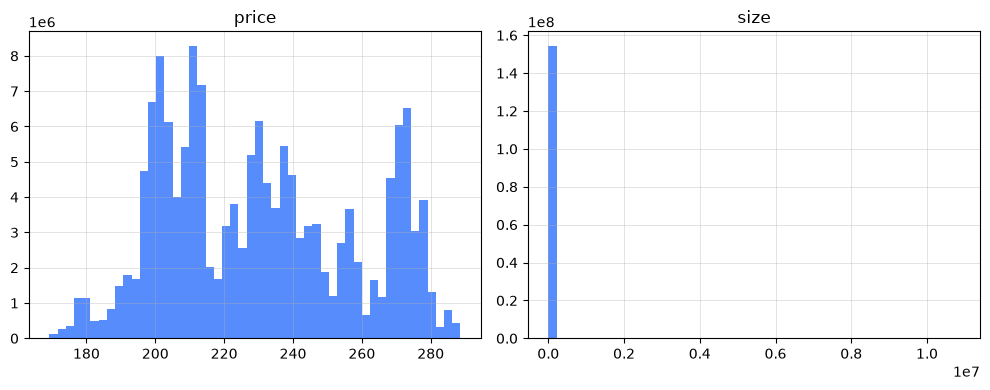

In [6]:
market_data[["price", "size"]].hist(bins=50, figsize=(10, 4))
plt.tight_layout()
plt.show()